Operating Point:
Flow Rate: 26.26 L/s
Head: 46.55 m


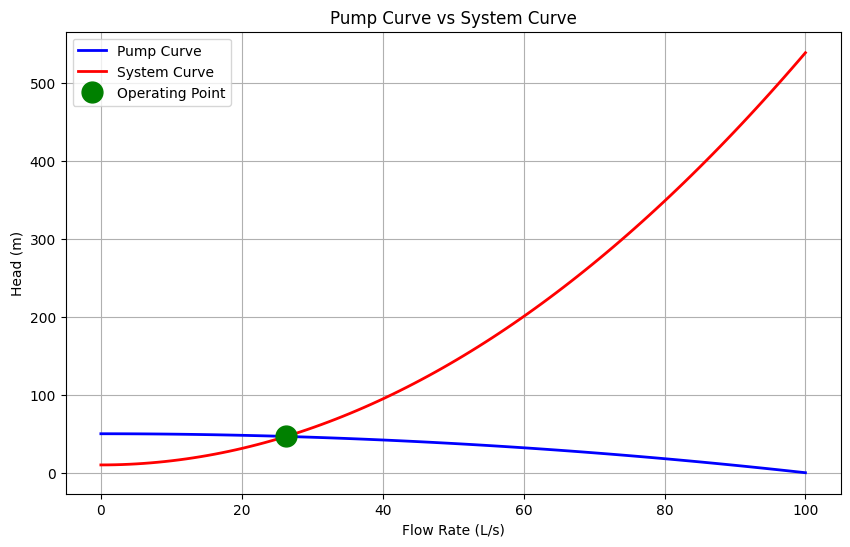

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Pump parameters (centrifugal pump)
rho = 1000      # water density kg/m3
g = 9.81        # gravity m/s2
D = 0.05        # pipe diameter m
L = 10          # pipe length m
f = 0.02        # friction factor

# Pump curve coefficients (H = a - b*Q^2)
a = 50          # shutoff head (m)
b = 5000        # curve coefficient

# Simulate pump operating points
flow_rates = np.linspace(0, 0.1, 100)  # m3/s

# Pump head curve
pump_head = a - b * flow_rates**2

# System curve (static head + friction losses)
static_head = 10  # meters
friction_head = (8 * f * L) / (np.pi**2 * g * D**5) * flow_rates**2
system_head = static_head + friction_head

# Operating point (intersection)
diff = np.abs(pump_head - system_head)
op_idx = np.argmin(diff)
op_flow = flow_rates[op_idx]
op_head = pump_head[op_idx]

print(f"Operating Point:")
print(f"Flow Rate: {op_flow*1000:.2f} L/s")
print(f"Head: {op_head:.2f} m")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(flow_rates*1000, pump_head, 'b-', linewidth=2, label='Pump Curve')
plt.plot(flow_rates*1000, system_head, 'r-', linewidth=2, label='System Curve')
plt.plot(op_flow*1000, op_head, 'go', markersize=15, label=f'Operating Point')
plt.xlabel('Flow Rate (L/s)')
plt.ylabel('Head (m)')
plt.title('Pump Curve vs System Curve')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)
time_steps = 1000  # simulate 1000 time points

def generate_pump_data(time_steps, fault_type=None, fault_start=700):
    t = np.arange(time_steps)
    
    # Normal operating conditions
    flow_rate = 0.065 + np.random.normal(0, 0.002, time_steps)        # m3/s
    pressure = 35 + np.random.normal(0, 0.5, time_steps)              # m head
    vibration = 0.5 + np.random.normal(0, 0.05, time_steps)           # mm/s
    temperature = 25 + np.random.normal(0, 0.3, time_steps)           # celsius
    power = 15 + np.random.normal(0, 0.2, time_steps)                 # kW
    
    # Inject faults after fault_start
    if fault_type == 'bearing_wear':
        # Bearing wear → vibration increases, temperature rises
        fault_mask = t >= fault_start
        vibration[fault_mask] += np.linspace(0, 3, sum(fault_mask))
        temperature[fault_mask] += np.linspace(0, 15, sum(fault_mask))
        
    elif fault_type == 'cavitation':
        # Cavitation → flow drops, vibration spikes
        fault_mask = t >= fault_start
        flow_rate[fault_mask] -= np.linspace(0, 0.02, sum(fault_mask))
        vibration[fault_mask] += np.random.normal(2, 0.5, sum(fault_mask))
        
    elif fault_type == 'blockage':
        # Pipe blockage → flow drops, pressure increases
        fault_mask = t >= fault_start
        flow_rate[fault_mask] -= np.linspace(0, 0.03, sum(fault_mask))
        pressure[fault_mask] += np.linspace(0, 10, sum(fault_mask))
        power[fault_mask] += np.linspace(0, 5, sum(fault_mask))
    
    # Health label: 1 = healthy, 0 = faulty
    labels = np.ones(time_steps)
    if fault_type:
        labels[fault_start:] = 0
    
    df = pd.DataFrame({
        'time': t,
        'flow_rate': flow_rate,
        'pressure': pressure,
        'vibration': vibration,
        'temperature': temperature,
        'power': power,
        'health': labels,
        'fault_type': fault_type if fault_type else 'normal'
    })
    
    return df

# Generate datasets
normal_data = generate_pump_data(time_steps, fault_type=None)
bearing_data = generate_pump_data(time_steps, fault_type='bearing_wear')
cavitation_data = generate_pump_data(time_steps, fault_type='cavitation')
blockage_data = generate_pump_data(time_steps, fault_type='blockage')

# Combine all
all_data = pd.concat([normal_data, bearing_data, 
                       cavitation_data, blockage_data], 
                      ignore_index=True)

print("Dataset shape:", all_data.shape)
print("\nFault types:", all_data['fault_type'].unique())
print("\nHealthy samples:", sum(all_data['health']==1))
print("Faulty samples:", sum(all_data['health']==0))
all_data.head()

Dataset shape: (4000, 8)

Fault types: <ArrowStringArray>
['normal', 'bearing_wear', 'cavitation', 'blockage']
Length: 4, dtype: str

Healthy samples: 3100
Faulty samples: 900


,time,flow_rate,pressure,vibration,temperature,power,health,fault_type
0,0,0.065993,35.699678,0.466241,24.427658,14.827301,1.0,normal
1,1,0.064723,35.462317,0.492774,24.741884,14.993759,1.0,normal
2,2,0.066295,35.029815,0.460379,24.875918,15.003603,1.0,normal
3,3,0.068046,34.676532,0.484602,25.566306,15.094526,1.0,normal
4,4,0.064532,35.349112,0.405319,25.166966,14.726628,1.0,normal


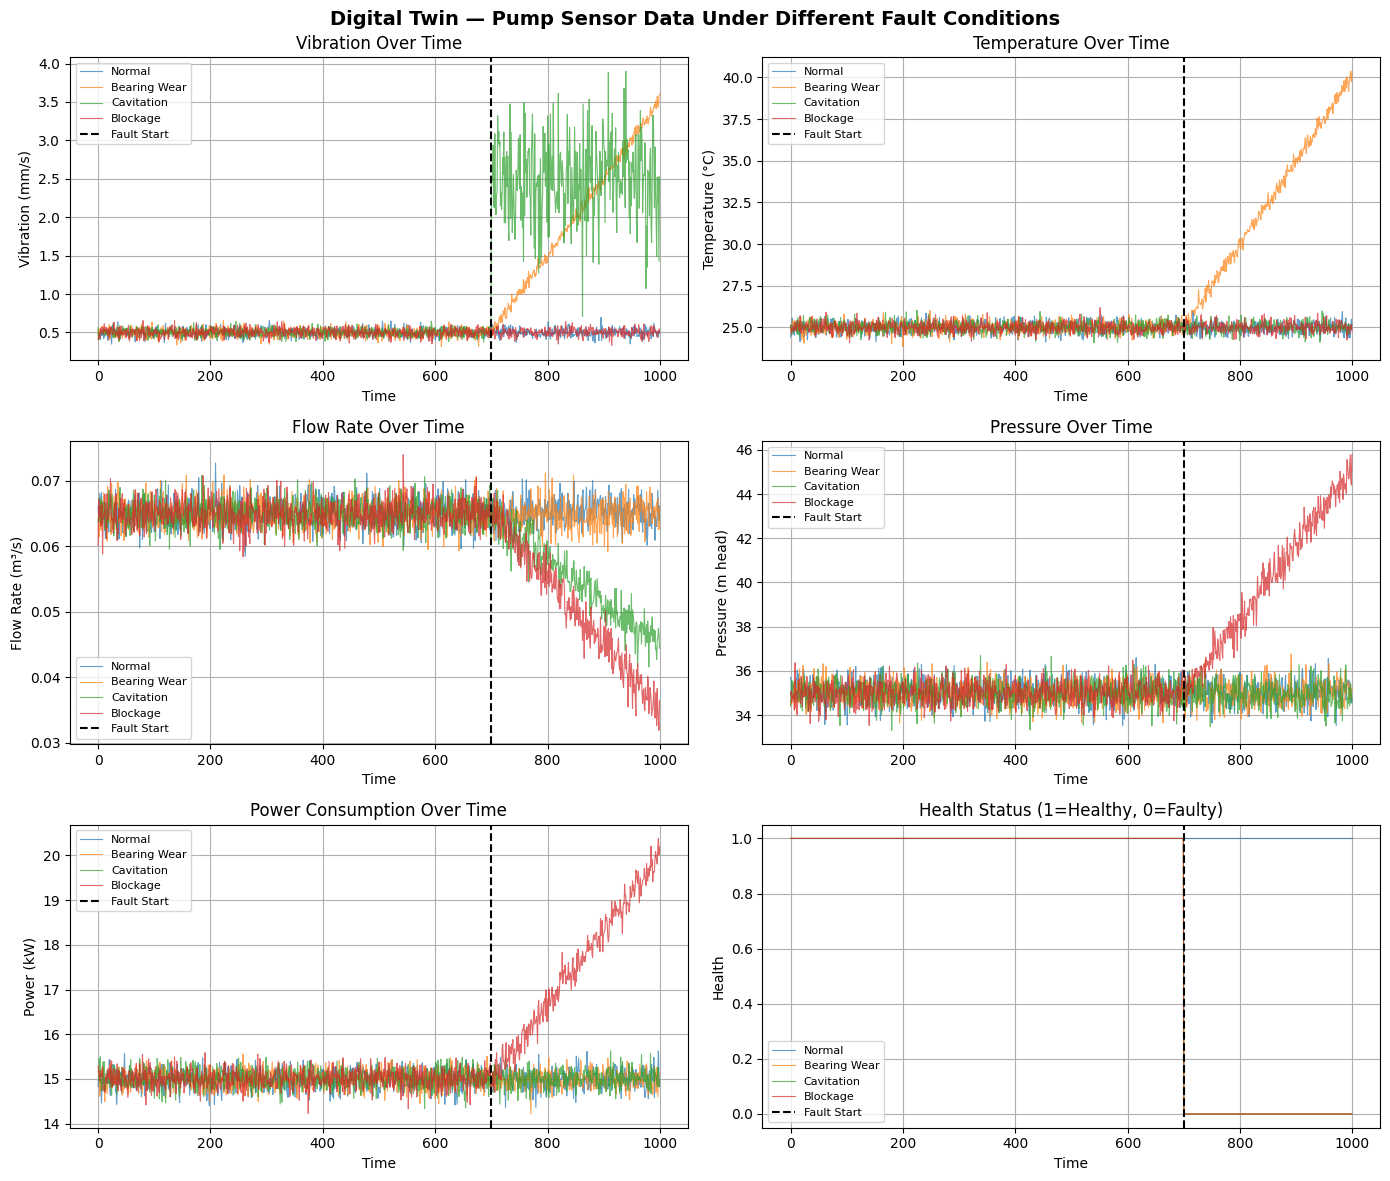

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

fault_colors = {
    'normal': 'blue',
    'bearing_wear': 'red', 
    'cavitation': 'orange',
    'blockage': 'purple'
}

datasets = {
    'Normal': normal_data,
    'Bearing Wear': bearing_data,
    'Cavitation': cavitation_data,
    'Blockage': blockage_data
}

# Vibration comparison
ax = axes[0, 0]
for name, data in datasets.items():
    ax.plot(data['time'], data['vibration'], 
            label=name, alpha=0.7, linewidth=0.8)
ax.axvline(x=700, color='black', linestyle='--', label='Fault Start')
ax.set_title('Vibration Over Time')
ax.set_xlabel('Time')
ax.set_ylabel('Vibration (mm/s)')
ax.legend(fontsize=8)
ax.grid(True)

# Temperature comparison
ax = axes[0, 1]
for name, data in datasets.items():
    ax.plot(data['time'], data['temperature'],
            label=name, alpha=0.7, linewidth=0.8)
ax.axvline(x=700, color='black', linestyle='--', label='Fault Start')
ax.set_title('Temperature Over Time')
ax.set_xlabel('Time')
ax.set_ylabel('Temperature (°C)')
ax.legend(fontsize=8)
ax.grid(True)

# Flow rate comparison
ax = axes[1, 0]
for name, data in datasets.items():
    ax.plot(data['time'], data['flow_rate'],
            label=name, alpha=0.7, linewidth=0.8)
ax.axvline(x=700, color='black', linestyle='--', label='Fault Start')
ax.set_title('Flow Rate Over Time')
ax.set_xlabel('Time')
ax.set_ylabel('Flow Rate (m³/s)')
ax.legend(fontsize=8)
ax.grid(True)

# Pressure comparison
ax = axes[1, 1]
for name, data in datasets.items():
    ax.plot(data['time'], data['pressure'],
            label=name, alpha=0.7, linewidth=0.8)
ax.axvline(x=700, color='black', linestyle='--', label='Fault Start')
ax.set_title('Pressure Over Time')
ax.set_xlabel('Time')
ax.set_ylabel('Pressure (m head)')
ax.legend(fontsize=8)
ax.grid(True)

# Power comparison
ax = axes[2, 0]
for name, data in datasets.items():
    ax.plot(data['time'], data['power'],
            label=name, alpha=0.7, linewidth=0.8)
ax.axvline(x=700, color='black', linestyle='--', label='Fault Start')
ax.set_title('Power Consumption Over Time')
ax.set_xlabel('Time')
ax.set_ylabel('Power (kW)')
ax.legend(fontsize=8)
ax.grid(True)

# Health status
ax = axes[2, 1]
for name, data in datasets.items():
    ax.plot(data['time'], data['health'],
            label=name, alpha=0.7, linewidth=0.8)
ax.axvline(x=700, color='black', linestyle='--', label='Fault Start')
ax.set_title('Health Status (1=Healthy, 0=Faulty)')
ax.set_xlabel('Time')
ax.set_ylabel('Health')
ax.legend(fontsize=8)
ax.grid(True)

plt.suptitle('Digital Twin — Pump Sensor Data Under Different Fault Conditions', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Prepare data
features = ['flow_rate', 'pressure', 'vibration', 'temperature', 'power']
X = all_data[features].values
y = all_data['health'].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create sequences for LSTM (window of 10 time steps)
def create_sequences(X, y, window=10):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y, window=10)

# Train test split
split = int(0.8 * len(X_seq))
X_train = torch.FloatTensor(X_seq[:split])
X_test = torch.FloatTensor(X_seq[split:])
y_train = torch.FloatTensor(y_seq[:split])
y_test = torch.FloatTensor(y_seq[split:])

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: torch.Size([3192, 10, 5])
Testing shape: torch.Size([798, 10, 5])


Training LSTM...
Epoch 5/20 - Loss: 0.6829
Epoch 10/20 - Loss: 0.6279
Epoch 15/20 - Loss: 0.5417
Epoch 20/20 - Loss: 0.3835

Training complete!


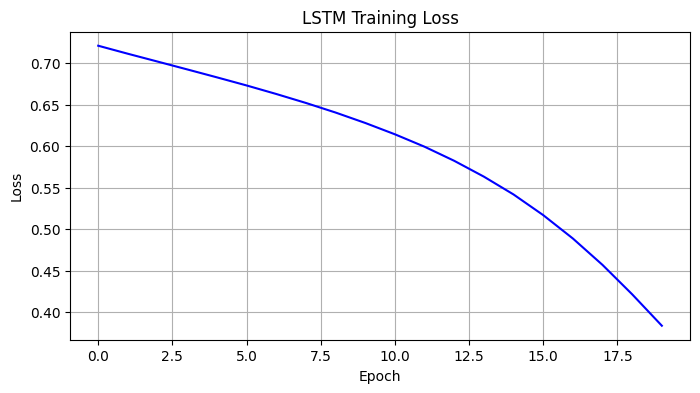

In [5]:
# Define LSTM model
class PumpLSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=64, num_layers=2):
        super(PumpLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, 
                           num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return self.sigmoid(out)

# Initialize model
model_lstm = PumpLSTM()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

# Train
epochs = 20
losses = []

print("Training LSTM...")
for epoch in range(epochs):
    model_lstm.train()
    optimizer.zero_grad()
    outputs = model_lstm(X_train).squeeze()
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")

print("\nTraining complete!")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(losses, color='blue')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [6]:
# Evaluate
model_lstm.eval()
with torch.no_grad():
    y_pred = model_lstm(X_test).squeeze()
    y_pred_binary = (y_pred > 0.5).float()

accuracy = accuracy_score(y_test.numpy(), y_pred_binary.numpy())
print(f"Accuracy: {accuracy*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test.numpy(), y_pred_binary.numpy(), 
                            target_names=['Faulty', 'Healthy']))

Accuracy: 65.66%

Detailed Report:
              precision    recall  f1-score   support

      Faulty       1.00      0.09      0.16       300
     Healthy       0.65      1.00      0.78       498

    accuracy                           0.66       798
   macro avg       0.82      0.54      0.47       798
weighted avg       0.78      0.66      0.55       798



In [7]:
# Train longer with more epochs
epochs = 100
losses = []

print("Training LSTM longer...")
for epoch in range(epochs):
    model_lstm.train()
    optimizer.zero_grad()
    outputs = model_lstm(X_train).squeeze()
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")

# Evaluate again
model_lstm.eval()
with torch.no_grad():
    y_pred = model_lstm(X_test).squeeze()
    y_pred_binary = (y_pred > 0.5).float()

accuracy = accuracy_score(y_test.numpy(), y_pred_binary.numpy())
print(f"\nNew Accuracy: {accuracy*100:.2f}%")

Training LSTM longer...
Epoch 20/100 - Loss: 0.1455
Epoch 40/100 - Loss: 0.0831
Epoch 60/100 - Loss: 0.0614
Epoch 80/100 - Loss: 0.0539
Epoch 100/100 - Loss: 0.0471

New Accuracy: 62.41%


In [10]:
from sklearn.utils import resample

# Balance the dataset
healthy = all_data[all_data['health'] == 1]
faulty = all_data[all_data['health'] == 0]

# Upsample faulty to match healthy
faulty_upsampled = resample(faulty, 
                            replace=True, 
                            n_samples=len(healthy), 
                            random_state=42)

balanced_data = pd.concat([healthy, faulty_upsampled])
balanced_data = balanced_data.sample(frac=1, random_state=42)

print("Balanced dataset:")
print(balanced_data['health'].value_counts())

# Recreate sequences with balanced data
X_bal = balanced_data[features].values
y_bal = balanced_data['health'].values

X_bal_scaled = scaler.fit_transform(X_bal)
X_seq_bal, y_seq_bal = create_sequences(X_bal_scaled, y_bal, window=10)

split = int(0.8 * len(X_seq_bal))
X_train = torch.FloatTensor(X_seq_bal[:split])
X_test = torch.FloatTensor(X_seq_bal[split:])
y_train = torch.FloatTensor(y_seq_bal[:split])
y_test = torch.FloatTensor(y_seq_bal[split:])

# Retrain fresh model
model_lstm = PumpLSTM()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)
loss

Balanced dataset:
health
0.0    3100
1.0    3100
Name: count, dtype: int64


tensor(0.0471, grad_fn=<BinaryCrossEntropyBackward0>)

In [12]:
# Reset everything first
import importlib
torch.manual_seed(42)

from sklearn.utils import resample

# Balance the dataset
healthy = all_data[all_data['health'] == 1]
faulty = all_data[all_data['health'] == 0]

faulty_upsampled = resample(faulty, 
                            replace=True, 
                            n_samples=len(healthy), 
                            random_state=42)

balanced_data = pd.concat([healthy, faulty_upsampled])
balanced_data = balanced_data.sample(frac=1, random_state=42)

print("Balanced dataset:")
print(balanced_data['health'].value_counts())

X_bal = balanced_data[features].values
y_bal = balanced_data['health'].values

X_bal_scaled = scaler.fit_transform(X_bal)
X_seq_bal, y_seq_bal = create_sequences(X_bal_scaled, y_bal, window=10)

split = int(0.8 * len(X_seq_bal))
X_train2 = torch.FloatTensor(X_seq_bal[:split])
X_test2 = torch.FloatTensor(X_seq_bal[split:])
y_train2 = torch.FloatTensor(y_seq_bal[:split])
y_test2 = torch.FloatTensor(y_seq_bal[split:])

# Brand new model
model2 = PumpLSTM()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)
criterion2 = nn.BCELoss()

print("\nRetraining on balanced data...")
for epoch in range(100):
    model2.train()
    optimizer2.zero_grad()
    outputs = model2(X_train2).squeeze()
    loss = criterion2(outputs, y_train2)
    loss.backward()
    optimizer2.step()
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/100 - Loss: {loss.item():.4f}")

model2.eval()
with torch.no_grad():
    y_pred2 = model2(X_test2).squeeze()
    y_pred_binary2 = (y_pred2 > 0.5).float()

accuracy2 = accuracy_score(y_test2.numpy(), y_pred_binary2.numpy())
print(f"\nNew Accuracy: {accuracy2*100:.2f}%")
print(classification_report(y_test2.numpy(), y_pred_binary2.numpy(),
                            target_names=['Faulty', 'Healthy']))

Balanced dataset:
health
0.0    3100
1.0    3100
Name: count, dtype: int64

Retraining on balanced data...
Epoch 20/100 - Loss: 0.6930
Epoch 40/100 - Loss: 0.6924
Epoch 60/100 - Loss: 0.6909
Epoch 80/100 - Loss: 0.6884
Epoch 100/100 - Loss: 0.6833

New Accuracy: 50.08%
              precision    recall  f1-score   support

      Faulty       0.52      0.44      0.48       638
     Healthy       0.49      0.57      0.52       600

    accuracy                           0.50      1238
   macro avg       0.50      0.50      0.50      1238
weighted avg       0.50      0.50      0.50      1238



Accuracy: 99.60%

Detailed Report:
              precision    recall  f1-score   support

      Faulty       1.00      0.99      1.00       614
     Healthy       0.99      1.00      1.00       626

    accuracy                           1.00      1240
   macro avg       1.00      1.00      1.00      1240
weighted avg       1.00      1.00      1.00      1240



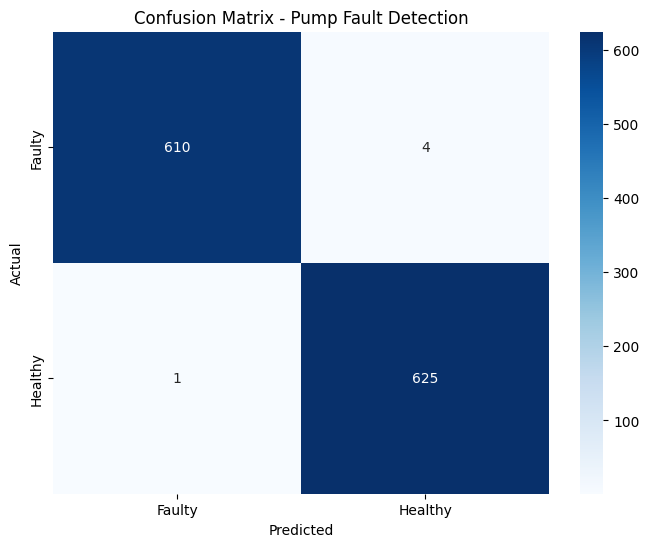

C:\Users\smrity\AppData\Local\Temp\ipykernel_14152\2639993253.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='Reds_r')


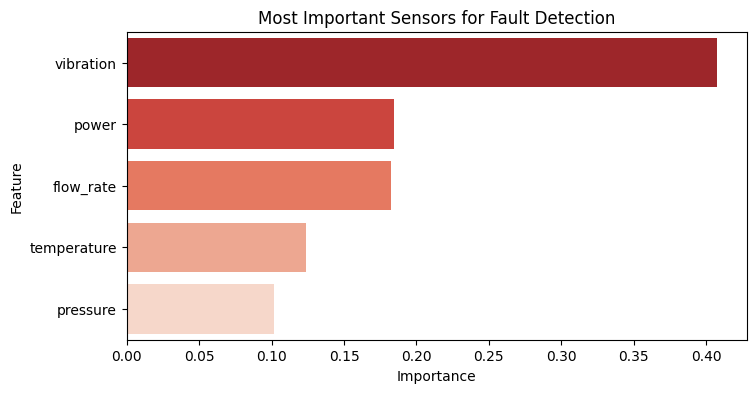

       Feature  Importance
2    vibration    0.407713
4        power    0.184652
0    flow_rate    0.182162
3  temperature    0.124000
1     pressure    0.101472


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

# Use balanced data directly (no sequences needed)
X_bal_rf = balanced_data[features].values
y_bal_rf = balanced_data['health'].values

# Scale
from sklearn.preprocessing import StandardScaler
scaler_rf = StandardScaler()
X_bal_rf_scaled = scaler_rf.fit_transform(X_bal_rf)

# Split
from sklearn.model_selection import train_test_split
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_bal_rf_scaled, y_bal_rf, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

# Evaluate
y_pred_rf = rf_model.predict(X_test_rf)
accuracy_rf = accuracy_score(y_test_rf, y_pred_rf)

print(f"Accuracy: {accuracy_rf*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test_rf, y_pred_rf,
                            target_names=['Faulty', 'Healthy']))

# Confusion Matrix
cm = confusion_matrix(y_test_rf, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Faulty', 'Healthy'],
            yticklabels=['Faulty', 'Healthy'])
plt.title('Confusion Matrix - Pump Fault Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature Importance
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='Reds_r')
plt.title('Most Important Sensors for Fault Detection')
plt.show()

print(feat_imp)